In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
BASE = '/content/drive/MyDrive/AMS25'
sys.path.insert(0, BASE)
os.chdir(BASE)

import torch
print(torch.cuda.get_device_name(0))

Mounted at /content/drive
Tesla T4


In [2]:
# ucitavanje i priprema podataka

# dataset.py
import os, pandas as pd, numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

# ── Spoji sva 4 dataseta ───────────────────────────────────────────
DATASETS = [
    (f'{BASE}/Dataset_DugeAnatomije_NSpine_HeraAT', 'anotacije_*.csv'),
    (f'{BASE}/Dataset_HeraAT',                      'anotacije_*.csv'),
    (f'{BASE}/Dataset_NSpine',                      'anotacije_*.csv'),
    (f'{BASE}/Dataset_Nspine_Jul24',                'anotacije_nspine_jul24.csv'),
]

def load_all_annotations(datasets=DATASETS):
    dfs = []
    for folder, pattern in datasets:
        import glob
        csv_files = glob.glob(os.path.join(folder, pattern))
        for csv_path in csv_files:
            df = pd.read_csv(csv_path)
            df['folder'] = folder  # dodaj kolonu da znamo odakle je slika
            dfs.append(df)
    combined = pd.concat(dfs, ignore_index=True)
    combined = combined.dropna()
    combined = combined[combined['Oznaka'].isin([0,1,2,3,4])]
    return combined

In [ ]:
# Provera da li treba dodati tezine na cross entropy loss

In [13]:
df = load_all_annotations()
print(df['Oznaka'].value_counts().sort_index())
print(f"\nUkupno: {len(df)}")

Oznaka
0     201
1     200
2     404
3     403
4    1144
Name: count, dtype: int64

Ukupno: 2352


In [3]:
class XrayPairDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform or T.Compose([
            T.Resize((128, 128)),   # upsample sa 190→128 (ili 224)
            T.ToTensor(),
            T.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        folder = row['folder']

        img_a = Image.open(os.path.join(folder, row['Slika_A'])).convert('L')
        img_b = Image.open(os.path.join(folder, row['Slika_B'])).convert('L')

        return (
            self.transform(img_a),
            self.transform(img_b),
            int(row['Oznaka'])
        )

def get_dataloaders(batch_size=32, val_ratio=0.15, test_ratio=0.15):
  df = load_all_annotations()
  dataset = XrayPairDataset(df)

  n = len(dataset)
  n_test = int(n * test_ratio)
  n_val  = int(n * val_ratio)
  n_train = n - n_val - n_test

  train_ds, val_ds, test_ds = random_split(
      dataset, [n_train, n_val, n_test],
      generator=__import__('torch').Generator().manual_seed(42)
  )

  return (
      DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=4),
      DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=4),
      DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=4),
  )

In [ ]:
# model

In [15]:
import torch, torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    """Shared CNN encoder: (B,1,128,128) → (B,256)"""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(1,  32),   # 128→64
            ConvBlock(32, 64),   # 64→32
            ConvBlock(64, 128),  # 32→16
            ConvBlock(128,256),  # 16→8
            ConvBlock(256, 256),  # 8→4  ← novo
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()           # → (B,256)
        )
    def forward(self, x):
        return self.net(x)

class SiamesePairClassifier(nn.Module):

#Ulaz:  img_a, img_b — svaki (B,1,128,128)
#Izlaz: logits (B,5) — klase 0=gore,1=dole,2=levo,3=desno,4=nije par

  def __init__(self, num_classes=5):
      super().__init__()
      self.encoder = Encoder()  # shared weights!
      self.head = nn.Sequential(
          nn.Linear(512, 256),  # 256+256 concat → 256
          nn.ReLU(inplace=True),
          nn.Dropout(0.4),
          nn.Linear(256, 128),
          nn.ReLU(inplace=True),
          nn.Linear(128, num_classes)
      )

  def forward(self, img_a, img_b):
      feat_a = self.encoder(img_a)  # (B,256)
      feat_b = self.encoder(img_b)  # (B,256)
      fused  = torch.cat([feat_a, feat_b], dim=1)  # (B,512)
      return self.head(fused)        # (B,5)

In [ ]:
# trening i evaluacija

In [16]:
# train.py
import torch, torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# from dataset import get_dataloaders
# from model import SiamesePairClassifier

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 30
LR     = 1e-3
LABELS = ['gore', 'dole', 'levo', 'desno', 'nije_par']

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct = 0.0, 0
    for img_a, img_b, labels in loader:
        img_a, img_b = img_a.to(DEVICE), img_b.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(img_a, img_b)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n

def evaluate(model, loader, criterion):
  model.eval()
  total_loss, all_preds, all_true = 0.0, [], []
  with torch.no_grad():
      for img_a, img_b, labels in loader:
          img_a, img_b = img_a.to(DEVICE), img_b.to(DEVICE)
          labels_dev = labels.to(DEVICE)
          logits = model(img_a, img_b)
          loss   = criterion(logits, labels_dev)
          total_loss += loss.item() * len(labels)
          all_preds.extend(logits.argmax(1).cpu().numpy())
          all_true.extend(labels.numpy())

  n = len(loader.dataset)
  acc = (np.array(all_preds) == np.array(all_true)).mean()
  return total_loss / n, acc, all_preds, all_true

In [ ]:
# main

In [ ]:
# racunamo tezine za CrossEntropyLoss, zato sto najvise ima klase 4
# from dataset import load_all_annotations
# import numpy as np

# df = load_all_annotations()
# counts = df['Oznaka'].value_counts().sort_index().values.astype(float)
# w = 1.0 / counts
# w = w / w.sum() * len(counts)
# weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
# criterion = nn.CrossEntropyLoss(weight=weights)

In [17]:
def main():
    train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)

    model     = SiamesePairClassifier().to(DEVICE)
    #weights = torch.tensor([2.49, 2.50, 1.24, 1.24, 0.44], dtype=torch.float32).to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        print(f"Epoha {epoch:02d}/{EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val   loss={vl_loss:.4f} acc={vl_acc:.3f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), 'best_model.pt')
            print(f"  ✓ Novi best model sačuvan (val_acc={vl_acc:.3f})")

    # ── Finalna evaluacija na test setu ───────────────────────────────
    model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
    _, test_acc, preds, true = evaluate(model, test_loader, criterion)

    print(f"\n=== Test accuracy: {test_acc:.4f} ===")
    print(classification_report(true, preds, target_names=LABELS))
    print("Confusion matrix:")
    print(confusion_matrix(true, preds))

if __name__ == '__main__':
    main()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoha 01/30 | Train loss=1.2686 acc=0.459 | Val   loss=1.1585 acc=0.463
  ✓ Novi best model sačuvan (val_acc=0.463)
Epoha 02/30 | Train loss=1.1355 acc=0.470 | Val   loss=1.0570 acc=0.455
Epoha 03/30 | Train loss=1.0301 acc=0.525 | Val   loss=0.9635 acc=0.597
  ✓ Novi best model sačuvan (val_acc=0.597)
Epoha 04/30 | Train loss=0.9615 acc=0.626 | Val   loss=0.8303 acc=0.776
  ✓ Novi best model sačuvan (val_acc=0.776)
Epoha 05/30 | Train loss=0.8697 acc=0.729 | Val   loss=0.7466 acc=0.849
  ✓ Novi best model sačuvan (val_acc=0.849)
Epoha 06/30 | Train loss=0.7928 acc=0.802 | Val   loss=0.7049 acc=0.861
  ✓ Novi best model sačuvan (val_acc=0.861)
Epoha 07/30 | Train loss=0.7236 acc=0.850 | Val   loss=0.7062 acc=0.866
  ✓ Novi best model sačuvan (val_acc=0.866)
Epoha 08/30 | Train loss=0.7222 acc=0.851 | Val   loss=0.7387 acc=0.849
Epoha 09/30 | Train loss=0.6480 acc=0.893 | Val   loss=0.5784 acc=0.940
  ✓ Novi best model sačuvan (val_acc=0.940)
Epoha 10/30 | Train loss=0.6463 acc=0.891 | 

In [ ]:
# inference

In [18]:
import torch
import torchvision.transforms as T
from PIL import Image
#from model import SiamesePairClassifier

LABELS  = {0: 'gore', 1: 'dole', 2: 'levo', 3: 'desno', 4: 'nije_par'}
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
TRANSFORM = T.Compose([T.Resize((128,128)), T.ToTensor(), T.Normalize([0.5],[0.5])])

def load_model(checkpoint='best_model.pt'):
    model = SiamesePairClassifier()
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

def predict(model, path_a: str, path_b: str) -> dict:
    """
    Vraća stranu na prvom snimku na koju se nastavlja drugi.
    path_a, path_b: putanje do PNG fajlova (već obrađenih, 190x190)
    """
    img_a = TRANSFORM(Image.open(path_a).convert('L')).unsqueeze(0).to(DEVICE)
    img_b = TRANSFORM(Image.open(path_b).convert('L')).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(img_a, img_b)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()

    return {
    'strana':      LABELS[pred],
    'klasa':       int(pred),
    'pouzdanost':  float(probs[pred]),
    'sve_verovatnoce': {LABELS[i]: float(p) for i, p in enumerate(probs)}
  }

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Ukupno pogrešnih: 20


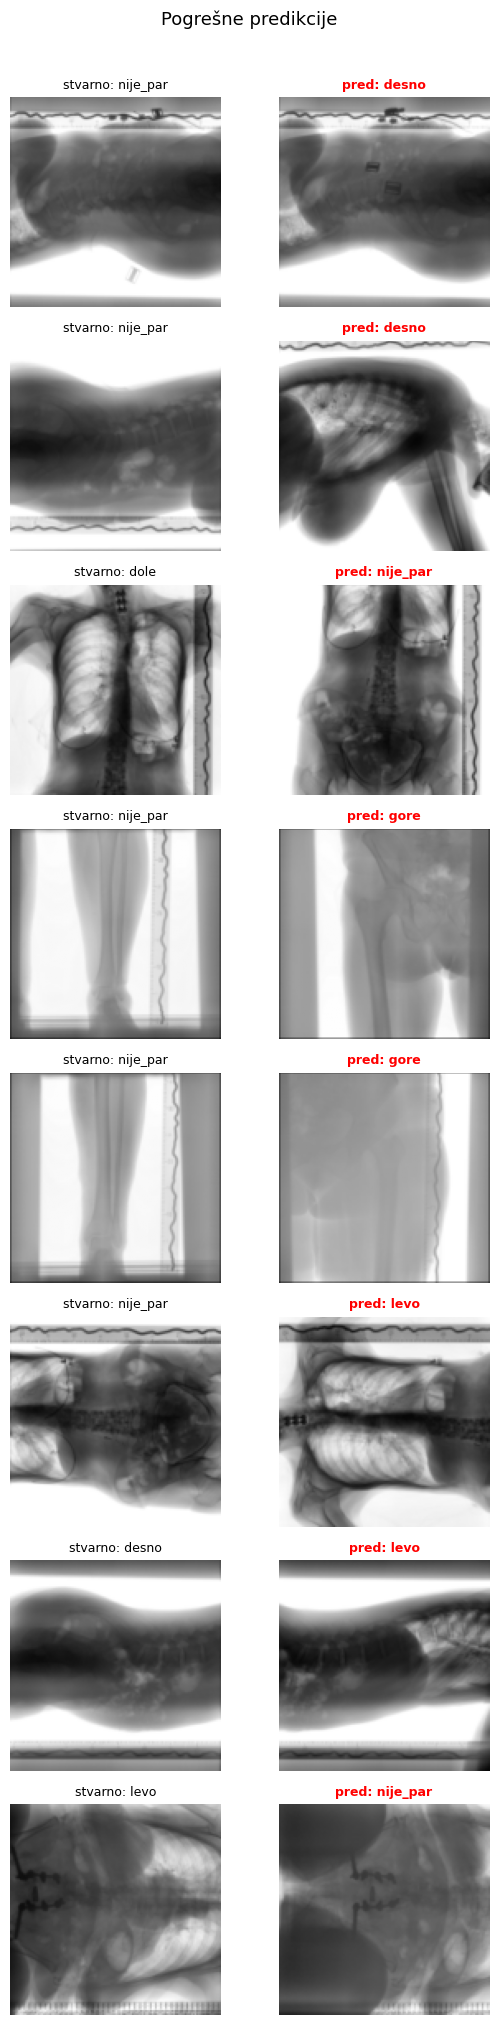

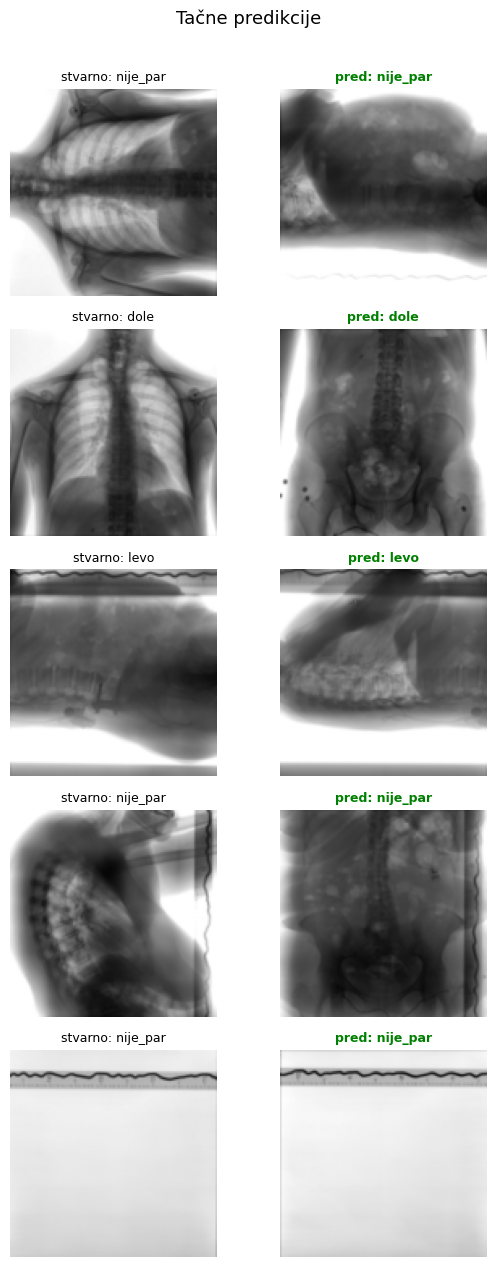

In [19]:
# vizuelna inspekcija — izvuci primere iz test seta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
#from dataset import get_dataloaders, XrayPairDataset, load_all_annotations
import torch

LABELS = ['gore', 'dole', 'levo', 'desno', 'nije_par']
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# učitaj model
#from model import SiamesePairClassifier
model = SiamesePairClassifier().to(DEVICE)
model.load_state_dict(torch.load('best_model.pt', map_location=DEVICE))
model.eval()

# rekonstruiši ISTI test split (isti seed = isti primeri)
_, _, test_loader = get_dataloaders(batch_size=1)

# skupi pogrešne i tačne primere
pogresni, tacni = [], []

with torch.no_grad():
    for img_a, img_b, label in test_loader:
        logit = model(img_a.to(DEVICE), img_b.to(DEVICE))
        pred = logit.argmax(1).item()
        true = label.item()
        entry = (img_a.squeeze(), img_b.squeeze(), true, pred)
        if pred != true:
            pogresni.append(entry)
        elif len(tacni) < 5:
            tacni.append(entry)

print(f"Ukupno pogrešnih: {len(pogresni)}")

# prikaz — 5 pogrešnih + 5 tačnih
def prikazi(primeri, naslov):
    fig, axes = plt.subplots(len(primeri), 2, figsize=(6, len(primeri) * 2.5))
    fig.suptitle(naslov, fontsize=13, y=1.01)
    if len(primeri) == 1:
        axes = [axes]

    for ax_row, (ia, ib, true, pred) in zip(axes, primeri):
        boja = 'green' if true == pred else 'red'

        for ax, img in zip(ax_row, [ia, ib]):
            ax.imshow(img.numpy(), cmap='gray', vmin=-1, vmax=1)
            ax.axis('off')

        # naslov iznad para — jasno vidljivo
        ax_row[0].set_title(
            f"stvarno: {LABELS[true]}",
            fontsize=9, color='black'
        )
        ax_row[1].set_title(
            f"pred: {LABELS[pred]}",
            fontsize=9, color=boja, fontweight='bold'
        )

    plt.tight_layout()
    plt.savefig(f'{naslov.replace(" ", "_")}.png', dpi=120, bbox_inches='tight')
    plt.show()

prikazi(pogresni[:8], 'Pogrešne predikcije')
prikazi(tacni[:5],    'Tačne predikcije')

In [ ]:
# koriscenje

In [20]:
if __name__ == '__main__':
    model = load_model('best_model.pt')
    rezultat = predict(
        model,
        '/content/111385000000002128_SCOLI_LAT_N_80_398.75_127.6_1.png',
        '/content/111385000000002139_SCOLI_LAT_N_80_398.89_179.5_1.png'
    )
    print(f"Drugi snimak se nastavlja na stranu: {rezultat['strana']}")
    print(f"Pouzdanost: {rezultat['pouzdanost']:.1%}")

Drugi snimak se nastavlja na stranu: dole
Pouzdanost: 87.0%
